In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_Day7.csv")


print(df.head())
print(df.info())

print(df.isnull().sum())

print(df.describe())

zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']
for col in zero_cols:
    print(f"{col} has {(df[col] == 0).sum()} zero values")

# replacing 0s with NaN so we can treat them as missing values
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

# now filling the missing values with median
for col in zero_cols:
    df[col] = df[col].fillna(df[col].median())

# confirming no more missing values
print(df.isnull().sum())

   Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age  \
0            6      148             72  33.6                     0.627   50   
1            1       85             66  26.6                     0.351   31   
2            8      183             64  23.3                     0.672   32   
3            1       89             66  28.1                     0.167   21   
4            0      137             40  43.1                     2.288   33   

   Outcome  
0        1  
1        0  
2        1  
3        0  
4        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   Diabetes

In [ ]:
original_len = len(df)
outlier_idx = set()

for col in df.columns:
    if col == 'Outcome':
        continue
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    print(f"{col}: {mask.sum()} outliers")
    outlier_idx.update(df[mask].index.tolist())

# checking how much data we are losing
pct = len(outlier_idx) / original_len * 100
print(f"\nTotal outlier rows: {len(outlier_idx)} which is {pct:.1f}% of data")

# since it is less than 30%, we can safely remove all outlier rows
df = df.drop(index=outlier_idx).reset_index(drop=True)
print(f"Rows remaining after removing outliers: {len(df)}")

Pregnancies: 4 outliers
Glucose: 0 outliers
BloodPressure: 14 outliers
BMI: 8 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers

Total outlier rows: 61 which is 7.9% of data
Rows remaining after removing outliers: 707


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=203)

# using Logistic Regression because Outcome is 0 or 1 — it's a classification problem
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# printing all the required metrics
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

# calculating AIC — lower AIC means better model
n_params = X_train.shape[1] + 1
log_likelihood = np.sum(y_test * np.log(y_prob + 1e-10) +
                        (1 - y_test) * np.log(1 - y_prob + 1e-10))
aic = 2 * n_params - 2 * log_likelihood
print("AIC       :", aic)

Accuracy  : 0.7464788732394366
Precision : 0.6290322580645161
Recall    : 0.5571428571428572
F1 Score  : 0.5909090909090909
AIC       : 219.97080882474262


Best Threshold : 0.25
Best F1 Score  : 0.6857


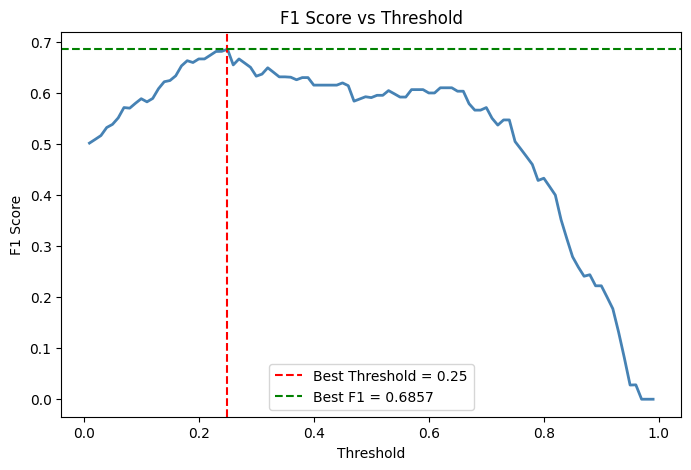

In [ ]:
import matplotlib.pyplot as plt

thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores  = []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    f1_scores.append(f1_t)

best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Best Threshold : {best_thresh:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(x=best_thresh, color='red', linestyle='--',label=f'Best Threshold = {best_thresh:.2f}')
plt.axhline(y=best_f1, color='green', linestyle='--',label=f'Best F1 = {best_f1:.4f}')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.show()